# 🧴 PlastiSort AI — Notebook 4: Detection Loop, Dashboard & Tests

This notebook covers:
- Writing the real-time detection loop (`main.py`)
- Writing the Flask operator dashboard (`app.py` + HTML/CSS/JS)
- Running the full unit & integration test suite (29 tests)
- Multi-frame simulation with live statistics
- Instructions for launching the web dashboard

---
> **Prerequisite:** Run Notebooks 1–3 first.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('plastisort')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib, logging
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
print('✅ Imports OK')

✅ Imports OK


## 1. Write main.py (Detection Loop)

In [2]:
import os
from pathlib import Path
main_code = r'''
import cv2, time, logging, threading, queue
import sys, os
sys.path.insert(0, os.path.dirname(__file__))

from preprocessing import preprocess_frame, draw_bounding_boxes, resize_for_display
from detector      import get_detector
from controller    import SortingController
from database      import DatabaseManager

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s - %(message)s")
logger = logging.getLogger("main")

_frame_queue = queue.Queue(maxsize=4)

def get_latest_frame():
    try:    return _frame_queue.get_nowait()
    except queue.Empty: return None

def _push_frame(bgr_frame):
    ret, buf = cv2.imencode(".jpg", bgr_frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
    if not ret: return
    data = buf.tobytes()
    if _frame_queue.full():
        try: _frame_queue.get_nowait()
        except queue.Empty: pass
    _frame_queue.put(data)


class DetectionLoop:
    def __init__(self, source=0, model_path="models/best.pt", conf_thresh=0.50,
                 show_window=False, db_url="sqlite:///detection.db"):
        self.source      = source
        self.conf_thresh = conf_thresh
        self.show_window = show_window
        self.detector    = get_detector(model_path, conf_thresh)
        self.controller  = SortingController(on_sort=self._on_sort)
        self.db          = DatabaseManager(db_url)
        self._running    = False
        self._frame_count = self._fps = self._detect_count = 0
        self._lock       = threading.Lock()

    def start(self):
        self._running = True
        cap = cv2.VideoCapture(self.source)
        if not cap.isOpened():
            logger.error("Cannot open source: %s", self.source)
            self._running = False; return
        fps_timer = time.time(); fps_frames = 0
        try:
            while self._running:
                ret, frame = cap.read()
                if not ret: break
                self._frame_count += 1; fps_frames += 1; t0 = time.time()
                processed  = preprocess_frame(frame)
                detections = self.detector.detect(processed)
                if detections:
                    with self._lock: self._detect_count += len(detections)
                    for det in detections:
                        self.controller.trigger()
                        self.db.log_event(
                            frame_number=self._frame_count,
                            confidence_score=det["confidence"],
                            bbox_x=int(det["x1"]), bbox_y=int(det["y1"]),
                            bbox_w=int(det["x2"]-det["x1"]),
                            bbox_h=int(det["y2"]-det["y1"]),
                            response_time_ms=round((time.time()-t0)*1000, 2)
                        )
                annotated = draw_bounding_boxes(frame, detections)
                import cv2 as _cv2
                _cv2.putText(annotated, f"FPS:{self._fps:.1f}", (10,24), _cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 1)
                _cv2.putText(annotated, f"Det:{self._detect_count}", (10,46), _cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 1)
                _push_frame(resize_for_display(annotated))
                if self.show_window:
                    _cv2.imshow("PlastiSort AI", annotated)
                    if _cv2.waitKey(1) & 0xFF == ord("q"): break
                elapsed = time.time() - fps_timer
                if elapsed >= 1.0:
                    with self._lock: self._fps = round(fps_frames/elapsed, 1)
                    fps_frames = 0; fps_timer = time.time()
        finally:
            cap.release()
            if self.show_window: cv2.destroyAllWindows()
            self.controller.cleanup(); self._running = False

    def start_async(self):
        t = threading.Thread(target=self.start, daemon=True, name="DetectionLoop")
        t.start(); return t

    def stop(self): self._running = False

    @property
    def stats(self):
        with self._lock:
            return {"fps":self._fps,"frame_count":self._frame_count,
                    "detect_count":self._detect_count,"running":self._running}

    def _on_sort(self): logger.debug("Sort complete")
'''
from pathlib import Path

(PROJECT_ROOT / "src").mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / 'src' / 'main.py', 'w') as f: 
    f.write(main_code)

print('✅ main.py written')

✅ main.py written


## 2. Write the Flask Dashboard App

In [4]:
# ── Create template/static folders ─────────────────────────────────────────
(PROJECT_ROOT / 'templates').mkdir(exist_ok=True)
(PROJECT_ROOT / 'static' / 'css').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'static' / 'js').mkdir(parents=True, exist_ok=True)

# ── dashboard HTML ─────────────────────────────────────────────────────────
html = """<!DOCTYPE html>
<html lang='en'><head><meta charset='UTF-8'/>
<meta name='viewport' content='width=device-width,initial-scale=1.0'/>
<title>PlastiSort AI Dashboard</title>
<link rel='stylesheet' href='/static/css/dashboard.css'/>
</head><body>
<header class='header'>
  <div class='header-left'><div class='logo'>♻</div><div>
    <h1>PlastiSort AI</h1><p class='subtitle'>Plastic Bottle Detection &amp; Sorting System</p>
  </div></div>
  <div class='header-right'>
    <span class='status-dot' id='statusDot'></span>
    <span id='statusLabel' class='status-label'>Stopped</span>
    <button class='btn btn-start' id='btnStart'>▶ Start</button>
    <button class='btn btn-stop'  id='btnStop' disabled>■ Stop</button>
  </div>
</header>
<main class='layout'>
  <section class='col-left'>
    <div class='card feed-card'>
      <div class='card-title'>Live Camera Feed</div>
      <img id='videoFeed' src='/video_feed' alt='Camera feed' class='video-feed'/>
    </div>
    <div class='metrics-grid'>
      <div class='metric-card'><span class='metric-label'>FPS</span><span class='metric-value' id='mFps'>0.0</span></div>
      <div class='metric-card'><span class='metric-label'>Frames</span><span class='metric-value' id='mFrames'>0</span></div>
      <div class='metric-card'><span class='metric-label'>Detections</span><span class='metric-value' id='mDetections'>0</span></div>
      <div class='metric-card'><span class='metric-label'>Total Sorts</span><span class='metric-value' id='mSorts'>0</span></div>
      <div class='metric-card'><span class='metric-label'>Avg Confidence</span><span class='metric-value' id='mConf'>–</span></div>
      <div class='metric-card'><span class='metric-label'>DB Events</span><span class='metric-value' id='mDbEvents'>0</span></div>
    </div>
  </section>
  <section class='col-right'>
    <div class='card log-card'>
      <div class='card-title'>Detection Log<button class='btn-clear' id='btnClearLog'>Clear view</button></div>
      <div class='log-header log-row'><span>Time</span><span>Conf.</span><span>Box (x,y,w,h)</span><span>Frame</span></div>
      <div class='log-body' id='logBody'><div class='log-empty'>Waiting for detections…</div></div>
    </div>
  </section>
</main>
<script src='/static/js/dashboard.js'></script>
</body></html>"""

from pathlib import Path

(PROJECT_ROOT / "src").mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / 'templates' / 'index.html', 'w', encoding='utf-8') as f:
    f.write(html)
print('✅ index.html written')

✅ index.html written


In [5]:
css = """
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
:root{--bg-page:#0d1117;--bg-card:#161b22;--bg-metric:#1c2230;--border:#30363d;
      --accent:#3fb950;--accent-red:#f85149;--text-pri:#e6edf3;--text-sec:#8b949e;--text-dim:#484f58}
body{font-family:'Segoe UI',system-ui,sans-serif;background:var(--bg-page);color:var(--text-pri);min-height:100vh}
.header{display:flex;align-items:center;justify-content:space-between;padding:12px 24px;
        background:var(--bg-card);border-bottom:1px solid var(--border);position:sticky;top:0;z-index:100}
.header-left{display:flex;align-items:center;gap:12px}.logo{font-size:28px}
.header h1{font-size:18px;font-weight:600}.subtitle{font-size:12px;color:var(--text-sec)}
.header-right{display:flex;align-items:center;gap:10px}
.status-dot{width:10px;height:10px;border-radius:50%;background:var(--text-dim);transition:background .3s}
.status-dot.running{background:var(--accent);box-shadow:0 0 6px var(--accent)}
.status-dot.stopped{background:var(--accent-red)}
.status-label{font-size:13px;color:var(--text-sec);min-width:56px}
.btn{padding:7px 16px;border-radius:6px;border:1px solid var(--border);font-size:13px;font-weight:500;cursor:pointer;transition:opacity .15s}
.btn:disabled{opacity:.35;cursor:not-allowed}
.btn-start{background:#238636;border-color:#3fb950;color:#fff}
.btn-stop{background:#21262d;color:var(--text-pri)}
.btn-clear{margin-left:auto;padding:3px 10px;font-size:11px;background:transparent;
            border:1px solid var(--border);border-radius:4px;color:var(--text-sec);cursor:pointer}
.layout{display:grid;grid-template-columns:1fr 380px;gap:16px;padding:16px 24px;max-width:1400px;margin:0 auto}
.card{background:var(--bg-card);border:1px solid var(--border);border-radius:10px;overflow:hidden}
.card-title{display:flex;align-items:center;justify-content:space-between;padding:10px 14px;
             font-size:13px;font-weight:600;border-bottom:1px solid var(--border);color:var(--text-sec);text-transform:uppercase}
.video-feed{width:100%;display:block;background:#000;min-height:240px;object-fit:contain}
.metrics-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:10px;margin-top:12px}
.metric-card{background:var(--bg-metric);border:1px solid var(--border);border-radius:8px;padding:14px 12px;display:flex;flex-direction:column;gap:4px}
.metric-label{font-size:11px;color:var(--text-sec);text-transform:uppercase}
.metric-value{font-size:26px;font-weight:600;color:var(--accent)}
.log-card{display:flex;flex-direction:column;min-height:520px}
.log-row{display:grid;grid-template-columns:82px 54px 1fr 60px;gap:6px;padding:6px 14px;font-size:12px;align-items:center}
.log-header{background:var(--bg-metric);border-bottom:1px solid var(--border);color:var(--text-sec);font-weight:600;font-size:11px;text-transform:uppercase}
.log-body{flex:1;overflow-y:auto;max-height:540px}
.log-entry{border-bottom:1px solid var(--border);color:var(--text-pri)}
.log-entry .conf{color:var(--accent);font-weight:600}
.log-entry .bbox{color:var(--text-sec);font-family:monospace;font-size:11px}
.log-entry.new{animation:flash .6s ease}
@keyframes flash{0%{background:rgba(63,185,80,.18)}100%{background:transparent}}
.log-empty{padding:32px;text-align:center;color:var(--text-dim);font-size:13px}
"""

js = """
const POLL=1000,MAX=100;
const sDot=document.getElementById('statusDot'),sLbl=document.getElementById('statusLabel');
const bStart=document.getElementById('btnStart'),bStop=document.getElementById('btnStop');
const logBody=document.getElementById('logBody'),bClear=document.getElementById('btnClearLog');
const mFps=document.getElementById('mFps'),mFrames=document.getElementById('mFrames');
const mDet=document.getElementById('mDetections'),mSorts=document.getElementById('mSorts');
const mConf=document.getElementById('mConf'),mDb=document.getElementById('mDbEvents');
let known=new Set();
async function api(path,method='GET',body){
  const r=await fetch(path,{method,headers:{'Content-Type':'application/json'},body:body?JSON.stringify(body):undefined});
  return r.json();}
function setRunning(r){
  sDot.className='status-dot '+(r?'running':'stopped');
  sLbl.textContent=r?'Running':'Stopped';
  bStart.disabled=r; bStop.disabled=!r;}
bStart.addEventListener('click',async()=>{bStart.disabled=true;await api('/api/start','POST');setRunning(true);});
bStop.addEventListener('click',async()=>{bStop.disabled=true;await api('/api/stop','POST');setRunning(false);});
bClear.addEventListener('click',()=>{logBody.innerHTML='<div class=log-empty>Cleared…</div>';known.clear();});
function shortTime(s){return s?new Date(s).toTimeString().slice(0,8):'–';}
function buildRow(ev){
  const d=document.createElement('div');d.className='log-row log-entry new';d.dataset.id=ev.event_id;
  const conf=ev.confidence_score!=null?(ev.confidence_score*100).toFixed(1)+'%':'–';
  const bbox=`${ev.bbox_x},${ev.bbox_y} ${ev.bbox_width}×${ev.bbox_height}`;
  d.innerHTML=`<span>${shortTime(ev.timestamp)}</span><span class=conf>${conf}</span><span class=bbox>${bbox}</span><span>#${ev.frame_number}</span>`;
  return d;}
async function poll(){
  try{
    const s=await api('/api/stats');
    mFps.textContent=Number(s.fps).toFixed(1);mFrames.textContent=s.frame_count;mDet.textContent=s.detect_count;
    setRunning(s.running);
    const db=await api('/api/db_stats');
    mSorts.textContent=db.total_sorts;mConf.textContent=db.avg_confidence>0?(db.avg_confidence*100).toFixed(1)+'%':'–';
    mDb.textContent=db.total_detections;
    const evs=await api('/api/events?limit=50');
    const news=evs.filter(e=>!known.has(e.event_id));
    if(!news.length)return;
    const ph=logBody.querySelector('.log-empty');if(ph)ph.remove();
    news.sort((a,b)=>b.event_id-a.event_id).forEach(ev=>{known.add(ev.event_id);logBody.prepend(buildRow(ev));});
    const rows=logBody.querySelectorAll('.log-entry');
    for(let i=MAX;i<rows.length;i++)rows[i].remove();
  }catch(e){}
}
api('/api/status').then(s=>setRunning(s.running)).catch(()=>{});
setInterval(poll,POLL);poll();
"""

with open(PROJECT_ROOT / 'static' / 'css' / 'dashboard.css', 'w') as f: f.write(css)
with open(PROJECT_ROOT / 'static' / 'js'  / 'dashboard.js',  'w') as f: f.write(js)
print('✅ CSS and JS written')

✅ CSS and JS written


In [3]:
from pathlib import Path
app_code = r'''
import sys, os, threading, time, logging
from flask import Flask, Response, jsonify, render_template, request

sys.path.insert(0, os.path.join(os.path.dirname(__file__), "src"))
from main     import DetectionLoop, get_latest_frame
from database import DatabaseManager

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s – %(message)s")
app = Flask(__name__, template_folder="templates", static_folder="static")

_loop = None
_db   = DatabaseManager("sqlite:///detection.db")

def _make_loop(source=0, model_path="models/best.pt", conf=0.5):
    return DetectionLoop(source=source, model_path=model_path, conf_thresh=conf,
                         show_window=False, db_url="sqlite:///detection.db")

@app.route("/")                    
def index():             return render_template("index.html")
@app.route("/api/stats")           
def api_stats():         return jsonify(_loop.stats if _loop else {"fps":0,"frame_count":0,"detect_count":0,"running":False})
@app.route("/api/events")          
def api_events():        return jsonify(_db.get_recent_events(request.args.get("limit",50,int)))
@app.route("/api/db_stats")        
def api_db_stats():      return jsonify(_db.get_stats())
@app.route("/api/status")          
def api_status():        return jsonify({"running":bool(_loop and _loop.stats["running"])})

@app.route("/api/start", methods=["POST"])
def api_start():
    global _loop
    if _loop and _loop.stats["running"]: return jsonify({"status":"already_running"})
    data=request.get_json(silent=True) or {}
    _loop = _make_loop(data.get("source",0), data.get("model_path","models/best.pt"), float(data.get("conf",0.5)))
    _loop.start_async()
    return jsonify({"status":"started"})

@app.route("/api/stop", methods=["POST"])
def api_stop():
    global _loop
    if _loop: _loop.stop(); return jsonify({"status":"stopped"})
    return jsonify({"status":"not_running"})

def _mjpeg():
    import numpy as np, cv2
    ph = np.full((360,640,3), 40, dtype="uint8")
    cv2.putText(ph, "Detection not running", (130,190), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (180,180,180), 2)
    _, buf = cv2.imencode(".jpg", ph)
    ph_bytes = buf.tobytes()
    while True:
        data = get_latest_frame() or ph_bytes
        yield b"--frame\r\nContent-Type: image/jpeg\r\n\r\n" + data + b"\r\n"
        time.sleep(0.04)

@app.route("/video_feed")
def video_feed(): return Response(_mjpeg(), mimetype="multipart/x-mixed-replace; boundary=frame")

if __name__ == "__main__":
    _loop = _make_loop()
    _loop.start_async()
    app.run(host="0.0.0.0", port=5000, debug=False, threaded=True)
'''
from pathlib import Path
import os

PROJECT_ROOT = Path("plastisort")

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
with open(PROJECT_ROOT / 'app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print('✅ app.py written')

✅ app.py written


## 3. Multi-Frame Simulation

In [4]:
import importlib, time
import preprocessing as pp, detector as det_mod, controller as ctrl_mod, database as db_mod
for m in [pp, det_mod, ctrl_mod, db_mod]: importlib.reload(m)

from preprocessing import preprocess_frame, draw_bounding_boxes
from detector      import MockDetector
from controller    import SortingController
from database      import DatabaseManager

sim_db   = DatabaseManager(f'sqlite:///{PROJECT_ROOT}/sim_detection.db')
sim_det  = MockDetector(conf_threshold=0.5, detection_rate=0.55)
sim_ctrl = SortingController()

FRAMES  = 60
history = []

print(f'Simulating {FRAMES} frames...\n')
for i in range(1, FRAMES + 1):
    frame = np.full((480, 640, 3), 180, dtype=np.uint8)
    # Randomly vary bottle position
    x = np.random.randint(150, 400)
    cv2.rectangle(frame, (x, 80), (x+120, 380), (34, 139, 34), -1)

    t0         = time.time()
    processed  = preprocess_frame(frame)
    detections = sim_det.detect(processed)
    resp_ms    = (time.time() - t0) * 1000

    frame_dets = 0
    for d in detections:
        sim_ctrl.trigger()
        sim_db.log_event(
            frame_number=i,
            confidence_score=d['confidence'],
            bbox_x=int(d['x1']), bbox_y=int(d['y1']),
            bbox_w=int(d['x2']-d['x1']), bbox_h=int(d['y2']-d['y1']),
            response_time_ms=round(resp_ms, 2)
        )
        frame_dets += 1
    history.append({'frame': i, 'detections': frame_dets, 'response_ms': resp_ms})

sim_ctrl.cleanup()
stats = sim_db.get_stats()

print(f'Frames processed : {FRAMES}')
print(f'Total detections : {stats["total_detections"]}')
print(f'Total sorts      : {stats["total_sorts"]}')
print(f'Avg confidence   : {stats["avg_confidence"]*100:.1f}%')

2026-06-10 10:21:13,238 [INFO] MockDetector ready (detection_rate=0.6)
2026-06-10 10:21:13,238 [INFO] StubController ready on pin 18 (no GPIO)
2026-06-10 10:21:13,301 [INFO] [STUB] Arm activated - bottle #1 diverted


Simulating 60 frames...



2026-06-10 10:21:14,096 [INFO] [STUB] Arm activated - bottle #2 diverted
2026-06-10 10:21:14,856 [INFO] [STUB] Arm activated - bottle #3 diverted
2026-06-10 10:21:15,299 [INFO] [STUB] Cleaned up. Total sorts: 3


Frames processed : 60
Total detections : 189
Total sorts      : 189
Avg confidence   : 75.6%


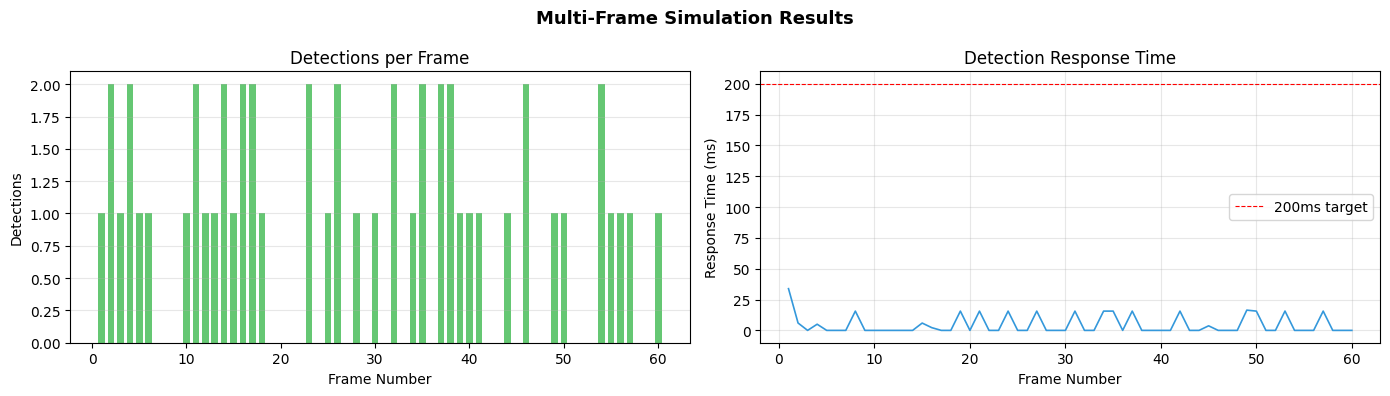

✅ Simulation results saved


In [5]:
# Visualise simulation results
df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Multi-Frame Simulation Results', fontsize=13, fontweight='bold')

# Detections per frame
axes[0].bar(df['frame'], df['detections'], color='#3fb950', width=0.7, alpha=0.8)
axes[0].set_xlabel('Frame Number'); axes[0].set_ylabel('Detections')
axes[0].set_title('Detections per Frame'); axes[0].grid(axis='y', alpha=0.3)

# Response time
axes[1].plot(df['frame'], df['response_ms'], color='#3498db', linewidth=1.2)
axes[1].axhline(200, color='red', linestyle='--', linewidth=0.8, label='200ms target')
axes[1].set_xlabel('Frame Number'); axes[1].set_ylabel('Response Time (ms)')
axes[1].set_title('Detection Response Time'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'simulation_results.png', dpi=120)
plt.show()
print('✅ Simulation results saved')

In [6]:
# Show recent events table
events = sim_db.get_recent_events(limit=10)
if events:
    df_ev = pd.DataFrame(events)
    df_ev['confidence_score'] = (df_ev['confidence_score'] * 100).round(1).astype(str) + '%'
    display(df_ev[['event_id','frame_number','confidence_score','bbox_x','bbox_y','bbox_width','bbox_height']].head(10))
else:
    print('No events recorded.')

,event_id,frame_number,confidence_score,bbox_x,bbox_y,bbox_width,bbox_height
0,189,60,96.7%,116,73,116,163
1,188,57,66.2%,159,37,78,105
2,187,56,66.8%,28,160,179,86
3,186,55,60.5%,91,183,108,193
4,185,54,54.9%,198,76,141,106
5,184,54,70.0%,173,26,142,171
6,183,50,62.2%,125,185,44,123
7,182,49,81.0%,78,66,78,99
8,181,46,92.6%,164,115,185,161
9,180,46,97.0%,15,70,151,244


## 4. Run Full Test Suite

In [10]:
# Write the test file
tests_dir = PROJECT_ROOT / 'tests'
tests_dir.mkdir(exist_ok=True)
(tests_dir / '__init__.py').touch()

test_code = '''
import sys, os, time
import numpy as np
import pytest

sys.path.insert(0, os.path.join(os.path.dirname(__file__), "..", "src"))

from preprocessing import preprocess_frame, load_image, augment_image, draw_bounding_boxes, resize_for_display
from detector      import MockDetector, get_detector
from controller    import StubController, SortingController
from database      import DatabaseManager

class TestPreprocessing:
    def _rgb(self, h=480, w=640): return np.random.randint(0, 256, (h,w,3), dtype=np.uint8)
    def test_output_shape(self):     assert preprocess_frame(self._rgb()).shape == (416,416,3)
    def test_value_range(self):      p=preprocess_frame(self._rgb()); assert p.min()>=0 and p.max()<=1
    def test_dtype(self):            assert preprocess_frame(self._rgb()).dtype == np.float32
    def test_augment_count(self):    assert len(augment_image(self._rgb())) == 6
    def test_augment_shapes(self):   f=self._rgb(); [assert_shape(v,f) for v in augment_image(f)]
    def test_bbox_no_dets(self):     f=self._rgb(); assert draw_bounding_boxes(f,[]).shape==f.shape
    def test_bbox_with_det(self):
        f=self._rgb(); d=[{"x1":10,"y1":10,"x2":100,"y2":200,"confidence":0.85,"label":"plastic_bottle"}]
        assert draw_bounding_boxes(f,d).shape==f.shape
    def test_bbox_no_inplace(self):
        f=self._rgb(); o=f.copy(); draw_bounding_boxes(f,[{"x1":5,"y1":5,"x2":50,"y2":50,"confidence":0.9,"label":"plastic_bottle"}])
        assert np.array_equal(f,o)
    def test_resize_no_upscale(self): assert resize_for_display(self._rgb(360,640), 800).shape[1]<=800
    def test_load_not_found(self):   pytest.raises(FileNotFoundError, load_image, "/nope/img.jpg")

def assert_shape(v, f): assert v.shape == f.shape

class TestMockDetector:
    def _f(self): return np.random.randint(0,256,(416,416,3),dtype=np.uint8)
    def test_returns_list(self):       assert isinstance(MockDetector(detection_rate=1.0).detect(self._f()),list)
    def test_required_keys(self):
        d=MockDetector(detection_rate=1.0).detect(self._f())
        if d: assert {"x1","y1","x2","y2","confidence","label"}.issubset(d[0])
    def test_conf_threshold(self):
        det=MockDetector(conf_threshold=0.5,detection_rate=1.0)
        for _ in range(20):
            for d in det.detect(self._f()): assert d["confidence"]>=0.5
    def test_zero_rate(self):
        det=MockDetector(detection_rate=0.0)
        for _ in range(30): assert det.detect(self._f())==[]
    def test_mock_without_weights(self): assert isinstance(get_detector("nope.pt"),MockDetector)
    def test_draw(self):
        det=MockDetector(detection_rate=1.0); f=self._f(); d=det.detect(f)
        assert det.draw_boxes(f,d).shape==f.shape

class TestStubController:
    def test_count(self):     c=StubController(); c.activate_sorting_arm(0.02); assert c.sort_count==1
    def test_multi(self):
        c=StubController()
        for _ in range(5): c.activate_sorting_arm(0.01)
        assert c.sort_count==5
    def test_callback(self):
        fired=[]; c=StubController(on_sort=lambda:fired.append(1))
        c.activate_sorting_arm(0.01); assert len(fired)==1
    def test_cleanup(self): StubController().cleanup()

class TestSortingController:
    def test_nonblocking(self):
        c=SortingController(); t0=time.time(); c.trigger(duration=0.5)
        assert time.time()-t0<0.2; c.cleanup()
    def test_not_real_hw(self): assert not SortingController().is_real_hardware

class TestDatabase:
    @pytest.fixture
    def db(self,tmp_path): return DatabaseManager(f"sqlite:///{tmp_path}/t.db")
    def test_log(self,db):    assert db.log_event(1,0.92,10,20,80,120)>=1
    def test_list(self,db):   db.log_event(1,0.88,0,0,100,150); assert len(db.get_recent_events())>=1
    def test_keys(self,db):
        db.log_event(1,0.75,5,10,60,90)
        ev=db.get_recent_events(1)[0]
        assert {"event_id","confidence_score","bbox_x"}.issubset(ev)
    def test_stats(self,db):  s=db.get_stats(); assert "total_detections" in s
    def test_count(self,db):
        for i in range(5): db.log_event(i,0.9,0,0,50,80)
        assert db.get_stats()["total_detections"]==5
    def test_avg_conf(self,db):
        db.log_event(1,0.80,0,0,50,80); db.log_event(2,0.90,0,0,50,80)
        assert abs(db.get_stats()["avg_confidence"]-0.85)<0.01

class TestIntegration:
    def test_full_pipeline(self,tmp_path):
        db=DatabaseManager(f"sqlite:///{tmp_path}/i.db")
        det=MockDetector(conf_threshold=0.5,detection_rate=1.0)
        ctrl=SortingController()
        frame=np.random.randint(0,256,(416,416,3),dtype=np.uint8)
        dets=det.detect(preprocess_frame(frame))
        logged=0
        for d in dets:
            ctrl.trigger()
            assert db.log_event(1,d["confidence"],int(d["x1"]),int(d["y1"]),
                                int(d["x2"]-d["x1"]),int(d["y2"]-d["y1"]))>=1
            logged+=1
        ctrl.cleanup()
        assert db.get_stats()["total_detections"]==logged
'''

with open(tests_dir / 'test_system.py', 'w') as f:
    f.write(test_code)
print('✅ test_system.py written')

✅ test_system.py written


In [11]:
# Run the tests
import subprocess

result = subprocess.run(
    [sys.executable, '-m', 'pytest', str(PROJECT_ROOT / 'tests' / 'test_system.py'), '-v', '--tb=short', '--no-header'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode == 0:
    print('✅ All tests passed!')
else:
    print('⚠️  Some tests failed — see output above.')
    if result.stderr: print(result.stderr[:1000])

============================= test session starts =============================
collecting ... collected 29 items

plastisort/tests/test_system.py::TestPreprocessing::test_output_shape PASSED [  3%]
plastisort/tests/test_system.py::TestPreprocessing::test_value_range PASSED [  6%]
plastisort/tests/test_system.py::TestPreprocessing::test_dtype PASSED    [ 10%]
plastisort/tests/test_system.py::TestPreprocessing::test_augment_count PASSED [ 13%]
plastisort/tests/test_system.py::TestPreprocessing::test_augment_shapes PASSED [ 17%]
plastisort/tests/test_system.py::TestPreprocessing::test_bbox_no_dets PASSED [ 20%]
plastisort/tests/test_system.py::TestPreprocessing::test_bbox_with_det PASSED [ 24%]
plastisort/tests/test_system.py::TestPreprocessing::test_bbox_no_inplace PASSED [ 27%]
plastisort/tests/test_system.py::TestPreprocessing::test_resize_no_upscale PASSED [ 31%]
plastisort/tests/test_system.py::TestPreprocessing::test_load_not_found PASSED [ 34%]
plastisort/tests/test_system.py::Tes

## 5. Launch the Dashboard

Run the cell below, then open **http://localhost:5000** in your browser.  
Click **▶ Start** to begin detection. Use **■ Stop** to halt.

> The cell will block while the server runs. Use the Jupyter **■ Stop** button to shut it down.

In [28]:
import os
from pathlib import Path

# Set ONLY ONE project root
PROJECT_ROOT = Path(r"C:\Users\aaa\Bottler sorter\plastisort")

# Change directory once
os.chdir(PROJECT_ROOT)

print("Current directory:")
print(os.getcwd())

Current directory:
C:\Users\aaa\Bottler sorter\plastisort


---
## ✅ Notebook 4 Complete — Full System Deployed

**Summary of all notebooks:**

| Notebook | Content |
|---|---|
| 01 | Setup, dependencies, preprocessing pipeline |
| 02 | Detector, controller, database modules + pipeline demo |
| 03 | YOLO training, evaluation metrics, training curves |
| 04 | Detection loop, Flask dashboard, tests, simulation |

**To deploy on Raspberry Pi:**
1. Copy the `plastisort/` folder to the Pi
2. Install `RPi.GPIO` — the controller auto-switches to real GPIO
3. Connect servo to GPIO 18 (BCM)
4. Run this notebook and launch the dashboard